In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=1) 
  
# data (as pandas dataframes) 
X = abalone.data.features 
y = abalone.data.targets 
  
# metadata 
print(abalone.metadata) 
  
# variable information 
print(abalone.variables) 


{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

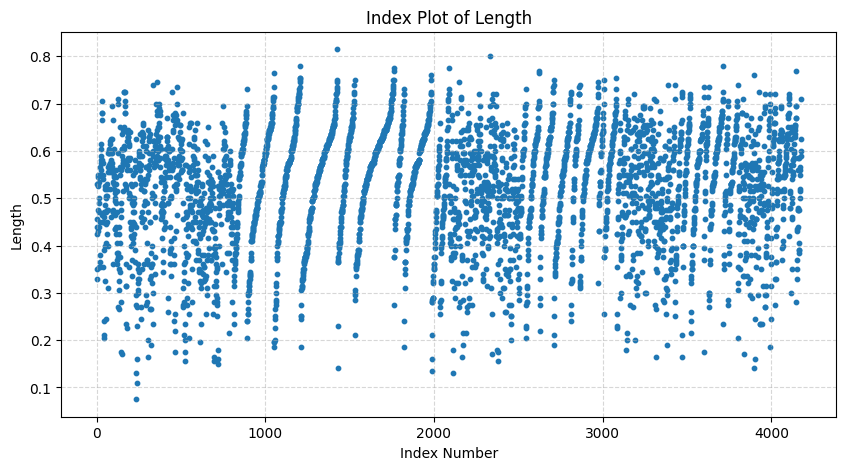

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 5))
plt.scatter(X.index, X['Length'], s=10, alpha=1)
plt.title('Index Plot of Length')
plt.xlabel('Index Number')
plt.ylabel('Length')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


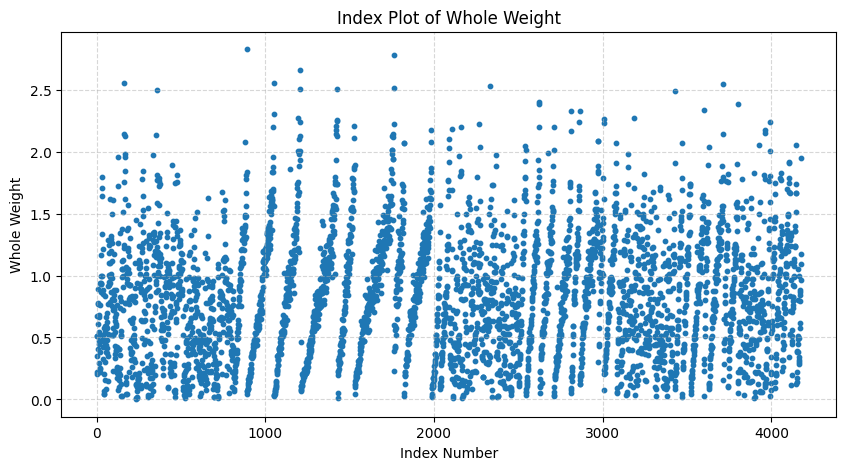

In [3]:
plt.figure(figsize=(10, 5))
plt.scatter(X.index, X['Whole_weight'], s=10, alpha=1)
plt.title('Index Plot of Whole Weight')
plt.xlabel('Index Number')
plt.ylabel('Whole Weight')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

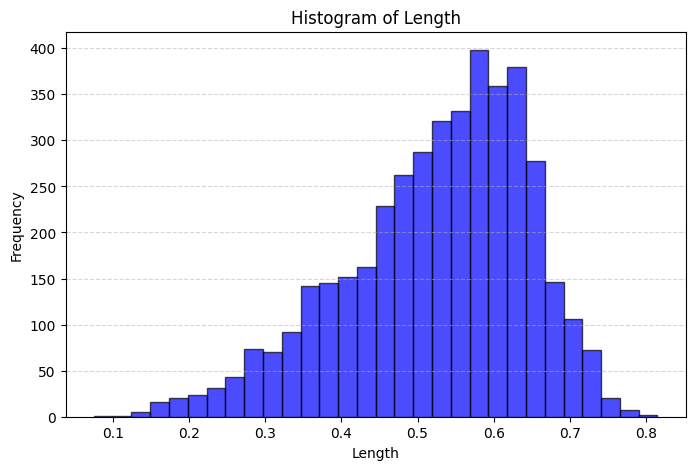

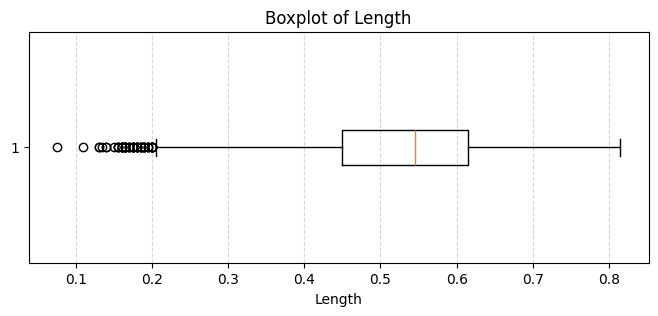

In [34]:
# histogram - length
plt.figure(figsize=(8, 5))
plt.hist(X['Length'], bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# boxplot - length
plt.figure(figsize=(8, 3))
plt.boxplot(X['Length'], vert=False)
plt.title('Boxplot of Length')
plt.xlabel('Length')
plt.grid(axis='x', linestyle='--', alpha=0.5)


plt.show()

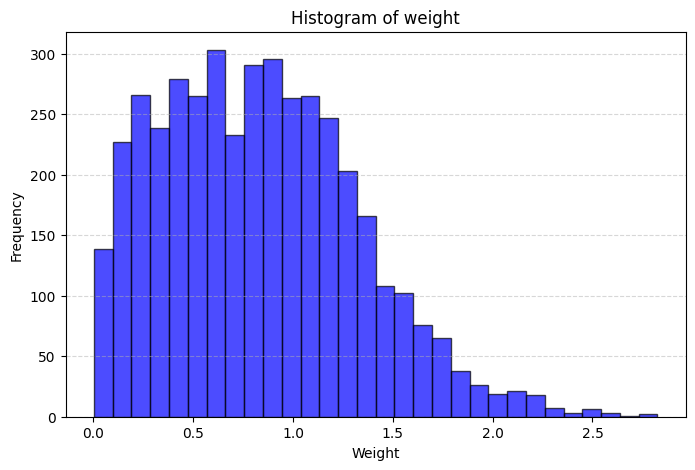

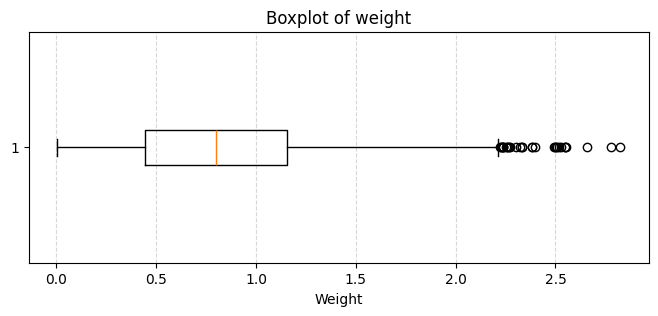

In [35]:
# histogram - weight
plt.figure(figsize=(8, 5))
plt.hist(X['Whole_weight'], bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.title('Histogram of weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# boxplot - weight
plt.figure(figsize=(8, 3))
plt.boxplot(X['Whole_weight'], vert=False)
plt.title('Boxplot of weight')
plt.xlabel('Weight')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

In [6]:
import pandas as pd

dict_length = {
    "min" : X["Length"].min(),
    "Q1" : X["Length"].quantile(0.25),
    "Median" : X["Length"].median(),
    "Q3" : X["Length"].quantile(0.75),
    "Max" : X["Length"].max(),
    "IQR" : X["Length"].quantile(0.75) - X["Length"].quantile(0.25)
}

pd.Series(dict_length, name="5-number summary for length")

min       0.075
Q1        0.450
Median    0.545
Q3        0.615
Max       0.815
IQR       0.165
Name: 5-number summary for length, dtype: float64

In [7]:
dict_weight = {
    "min" : X["Whole_weight"].min(),
    "Q1" : X["Whole_weight"].quantile(0.25),
    "Median" : X["Whole_weight"].median(),
    "Q3" : X["Whole_weight"].quantile(0.75),
    "Max" : X["Whole_weight"].max(),
    "IQR" : X["Whole_weight"].quantile(0.75) - X["Whole_weight"].quantile(0.25)
}

pd.Series(dict_weight, name="5-number summary for weight")

min       0.0020
Q1        0.4415
Median    0.7995
Q3        1.1530
Max       2.8255
IQR       0.7115
Name: 5-number summary for weight, dtype: float64

In [8]:
dict_length_2 = {
    "mean" : X["Length"].mean(),
    "sd" : X["Length"].std(),
    "variance" : X["Length"].var(),
    "kurtosis" : X["Length"].kurtosis(),
    "skewness" : X["Length"].skew()
}

pd.Series(dict_length_2, name="Moment based statistics for length")

mean        0.523992
sd          0.120093
variance    0.014422
kurtosis    0.064621
skewness   -0.639873
Name: Moment based statistics for length, dtype: float64

In [9]:
dict_weight_2 = {
    "mean" : X["Whole_weight"].mean(),
    "sd" : X["Whole_weight"].std(),
    "variance" : X["Whole_weight"].var(),
    "kurtosis" : X["Whole_weight"].kurtosis(),
    "skewness" : X["Whole_weight"].skew()
}

pd.Series(dict_weight_2, name="Moment based statistics for weight")

mean        0.828742
sd          0.490389
variance    0.240481
kurtosis   -0.023644
skewness    0.530959
Name: Moment based statistics for weight, dtype: float64

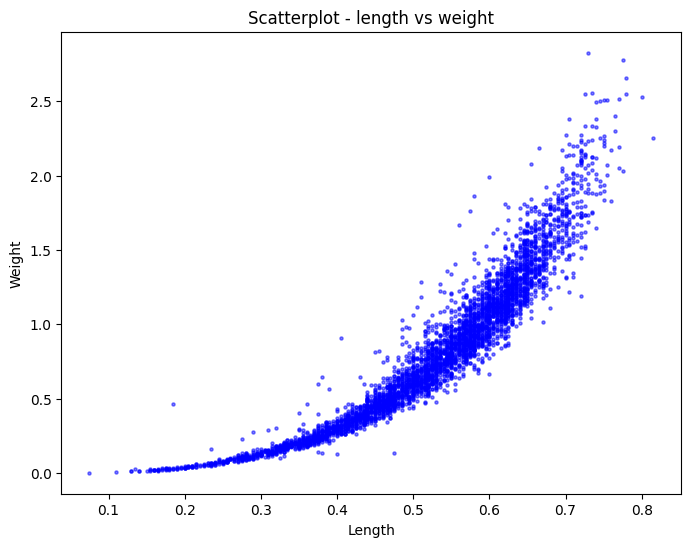

In [10]:
# scatter

plt.figure(figsize=(8, 6))
plt.scatter(X['Length'], X['Whole_weight'], s=5, alpha=0.5, color='blue')
plt.title('Scatterplot - length vs weight')
plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()

In [ ]:
# 6) outliers identification and removal - present outliers on the index
# plots and the scatter plot. Remove outliers from the dataset and present
# a second statistics table

# Calculate the spread of the middle 50% of the data
# Values below Q1 - 1.5*IQR or above Q3 +1.5*IQR) are considered outliers.

def weight_outliers():
    weight_Q1 = X["Whole_weight"].quantile(0.25)
    weight_Q3 = X["Whole_weight"].quantile(0.75)
    weight_IQR = weight_Q3-weight_Q1
    print('Q1: ',weight_Q1, '\n' 
          'Q3: ',weight_Q3, '\n'
          'IQR: ',weight_IQR)
    
    weight_up_outliers = weight_Q3+(1.5*weight_IQR)
    weight_down_outliers = weight_Q1-(1.5*weight_IQR)
    print('Gorny prog outlierow: ', weight_up_outliers)
    print('Dolny prog outlierow: ', weight_down_outliers)

    ident_weight_outliers = X[(X['Whole_weight'] < weight_down_outliers) | (X['Whole_weight'] > weight_up_outliers)]
    print(ident_weight_outliers)
    return weight_down_outliers, weight_up_outliers
weight_outliers()

Q1:  0.4415 
Q3:  1.153 
IQR:  0.7115
Gorny prog outlierow:  2.22025
Dolny prog outlierow:  -0.62575
     Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  \
165    M   0.725     0.570   0.190        2.5500          1.0705   
358    M   0.745     0.585   0.215        2.4990          0.9265   
891    M   0.730     0.595   0.230        2.8255          1.1465   
1051   F   0.735     0.600   0.220        2.5550          1.1335   
1052   M   0.765     0.600   0.220        2.3020          1.0070   
1193   M   0.700     0.575   0.190        2.2730          1.0950   
1206   F   0.750     0.570   0.210        2.2360          1.1090   
1207   F   0.755     0.625   0.210        2.5050          1.1965   
1209   F   0.780     0.630   0.215        2.6570          1.4880   
1426   F   0.745     0.570   0.215        2.2500          1.1565   
1427   F   0.750     0.610   0.235        2.5085          1.2320   
1428   F   0.815     0.650   0.250        2.2550          0.8905   
1761   M   0.75

(np.float64(-0.62575), np.float64(2.22025))

In [12]:
def length_outliers():
    length_Q1 = X["Length"].quantile(0.25)
    length_Q3 = X["Length"].quantile(0.75)
    length_IQR = length_Q3-length_Q1
    print('Q1: ',length_Q1, '\n' 
          'Q3: ',length_Q3, '\n'
          'IQR: ',length_IQR)
    
    length_up_outliers = length_Q3+(1.5*length_IQR)
    length_down_outliers = length_Q1-(1.5*length_IQR)
    print('Gorny prog outlierow: ', length_up_outliers)
    print('Dolny prog outlierow: ', length_down_outliers)

    ident_length_outliers = X[(X['Length'] < length_down_outliers) | (X['Length'] > length_up_outliers)]
    print(ident_length_outliers)
    return length_down_outliers, length_up_outliers
length_outliers()

Q1:  0.45 
Q3:  0.615 
IQR:  0.16499999999999998
Gorny prog outlierow:  0.8624999999999999
Dolny prog outlierow:  0.20250000000000004
     Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  \
148    I   0.175     0.130   0.055        0.0315          0.0105   
149    I   0.170     0.130   0.095        0.0300          0.0130   
236    I   0.075     0.055   0.010        0.0020          0.0010   
237    I   0.130     0.100   0.030        0.0130          0.0045   
238    I   0.110     0.090   0.030        0.0080          0.0025   
239    I   0.160     0.120   0.035        0.0210          0.0075   
305    I   0.200     0.145   0.060        0.0370          0.0125   
306    I   0.165     0.120   0.030        0.0215          0.0070   
321    I   0.190     0.145   0.040        0.0380          0.0165   
465    I   0.175     0.125   0.050        0.0235          0.0080   
523    M   0.200     0.140   0.055        0.0350          0.0145   
525    M   0.175     0.125   0.040        0.0240  

(np.float64(0.20250000000000004), np.float64(0.8624999999999999))

In [13]:
w_down, w_up = weight_outliers()
l_down, l_up = length_outliers()

is_weight_outlier = (X['Whole_weight'] < w_down) | (X['Whole_weight'] > w_up)
is_length_outlier = (X['Length'] < l_down) | (X['Length'] > l_up)

# indexing outlier for both categories
combined_outliers = is_weight_outlier | is_length_outlier

Q1:  0.4415 
Q3:  1.153 
IQR:  0.7115
Gorny prog outlierow:  2.22025
Dolny prog outlierow:  -0.62575
     Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  \
165    M   0.725     0.570   0.190        2.5500          1.0705   
358    M   0.745     0.585   0.215        2.4990          0.9265   
891    M   0.730     0.595   0.230        2.8255          1.1465   
1051   F   0.735     0.600   0.220        2.5550          1.1335   
1052   M   0.765     0.600   0.220        2.3020          1.0070   
1193   M   0.700     0.575   0.190        2.2730          1.0950   
1206   F   0.750     0.570   0.210        2.2360          1.1090   
1207   F   0.755     0.625   0.210        2.5050          1.1965   
1209   F   0.780     0.630   0.215        2.6570          1.4880   
1426   F   0.745     0.570   0.215        2.2500          1.1565   
1427   F   0.750     0.610   0.235        2.5085          1.2320   
1428   F   0.815     0.650   0.250        2.2550          0.8905   
1761   M   0.75

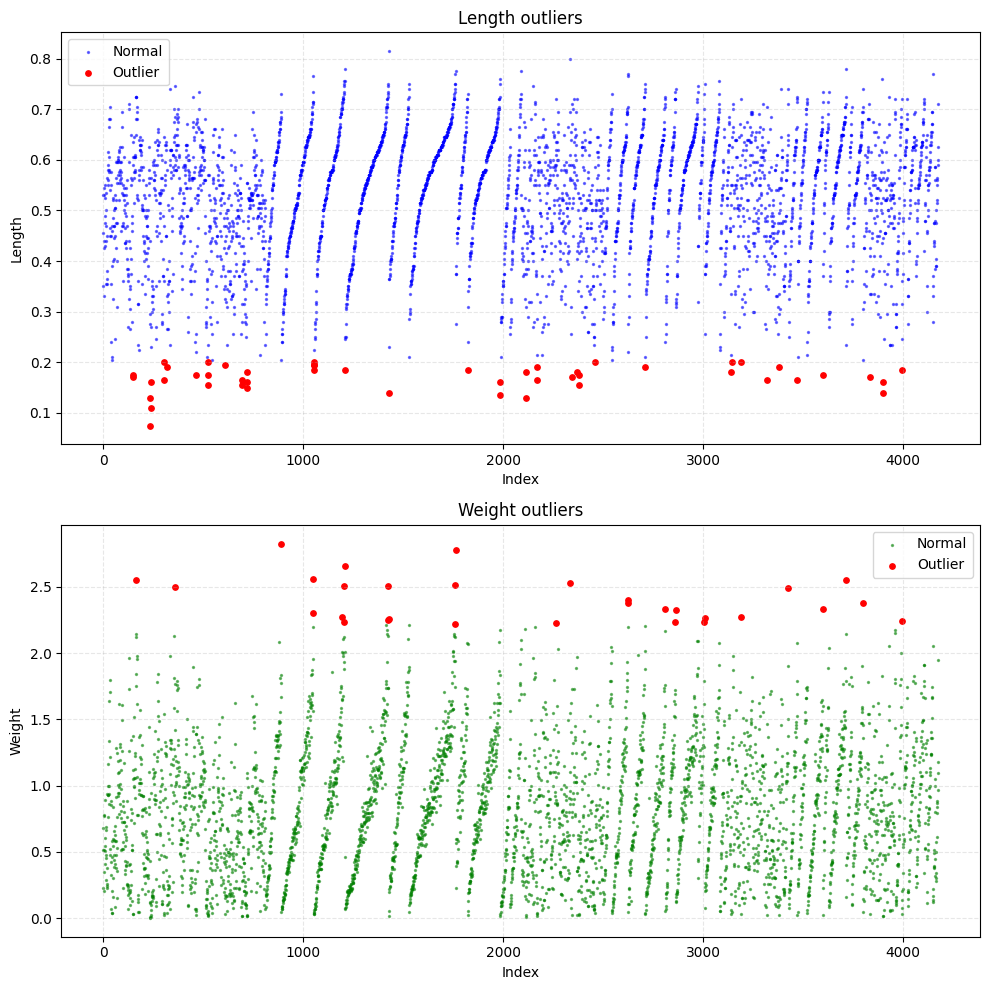

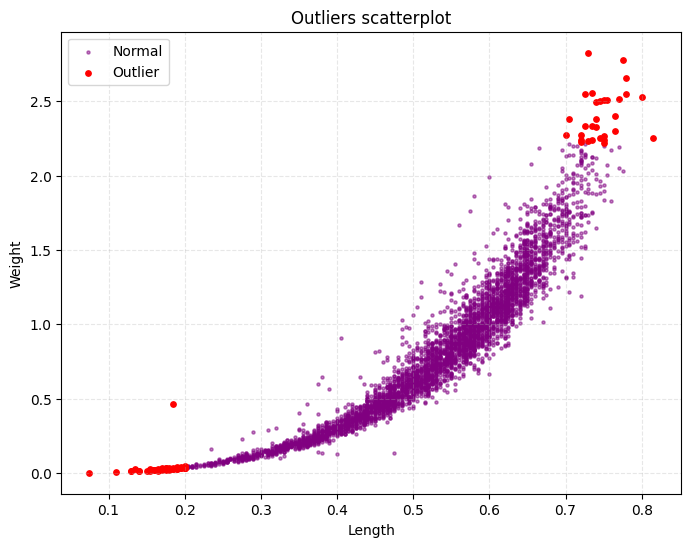

In [14]:

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# length plot
axes[0].scatter(X.index[~is_length_outlier], X['Length'][~is_length_outlier], s=2, alpha=0.5, color='blue', label='Normal')
axes[0].scatter(X.index[is_length_outlier], X['Length'][is_length_outlier], s=15, color='red', label='Outlier')
axes[0].set_title('Length outliers')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Length')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# weight plot
axes[1].scatter(X.index[~is_weight_outlier], X['Whole_weight'][~is_weight_outlier], s=2, alpha=0.5, color='green', label='Normal')
axes[1].scatter(X.index[is_weight_outlier], X['Whole_weight'][is_weight_outlier], s=15, color='red', label='Outlier')
axes[1].set_title('Weight outliers')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Weight')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


# scatter plot - outliers
plt.figure(figsize=(8, 6))
plt.scatter(X['Length'][~combined_outliers], X['Whole_weight'][~combined_outliers], 
            s=5, alpha=0.5, color='purple', label='Normal')
plt.scatter(X['Length'][combined_outliers], X['Whole_weight'][combined_outliers], 
            s=15, color='red', label='Outlier')
plt.title('Outliers scatterplot')
plt.xlabel('Length')
plt.ylabel('Weight')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [ ]:
new_X = X[~combined_outliers]

print(new_X)

# Calculate stats for the cleaned data
def no_outliers_stats(series):
    return {
        "Min": series.min(),
        "Q1": series.quantile(0.25),
        "Median": series.median(),
        "Q3": series.quantile(0.75),
        "Max": series.max(),
        "IQR": series.quantile(0.75) - series.quantile(0.25)
    }

clean_stats_length = no_outliers_stats(new_X['Length'])
clean_stats_weight = no_outliers_stats(new_X['Whole_weight'])

stats_df = pd.DataFrame([clean_stats_length, clean_stats_weight], index=['Length', 'Weight'])
print(stats_df)

     Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  \
0      M   0.455     0.365   0.095        0.5140          0.2245   
1      M   0.350     0.265   0.090        0.2255          0.0995   
2      F   0.530     0.420   0.135        0.6770          0.2565   
3      M   0.440     0.365   0.125        0.5160          0.2155   
4      I   0.330     0.255   0.080        0.2050          0.0895   
...   ..     ...       ...     ...           ...             ...   
4172   F   0.565     0.450   0.165        0.8870          0.3700   
4173   M   0.590     0.440   0.135        0.9660          0.4390   
4174   M   0.600     0.475   0.205        1.1760          0.5255   
4175   F   0.625     0.485   0.150        1.0945          0.5310   
4176   M   0.710     0.555   0.195        1.9485          0.9455   

      Viscera_weight  Shell_weight  
0             0.1010        0.1500  
1             0.0485        0.0700  
2             0.1415        0.2100  
3             0.1140        0.1550 

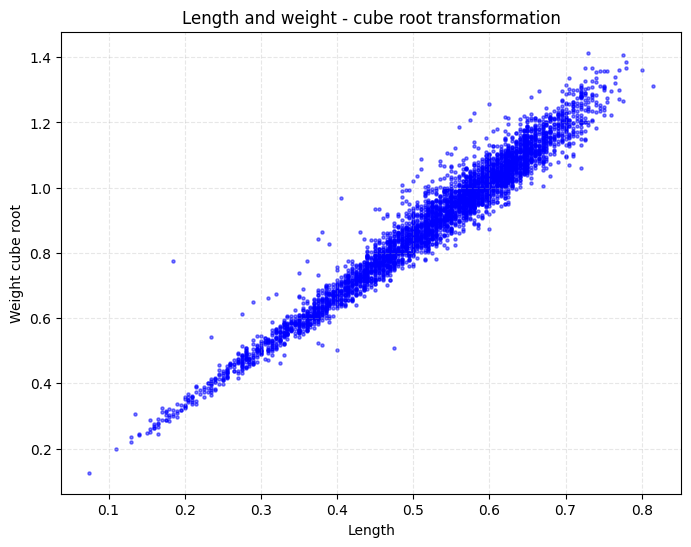

In [ ]:
# 7) transform the data (square root) so that the scatterplot
# exhibits a straight-line

import numpy as np

cube_root_weight = np.cbrt(X['Whole_weight'])

plt.figure(figsize=(8, 6))
plt.scatter(X['Length'], cube_root_weight, s=5, alpha=0.5, color='blue')
plt.title('Length and weight - cube root transformation')
plt.xlabel('Length')
plt.ylabel('Weight cube root')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [ ]:
# 8) fit a linear regression line to the transgormed data
# calculate the R^2 and mean squared error MSE

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_reg = X[['Length']]
y_reg = np.cbrt(X['Whole_weight'])

model = LinearRegression()
model.fit(X_reg, y_reg)
line = model.predict(X_reg)

# r2 and mse
r2 = r2_score(y_reg, line)
mse = mean_squared_error(y_reg, line)

print(f'R2 = ', r2)
print(f'MSE = ', mse)
print(f'Cube Root for weight = ', model.intercept_ + model.coef_)


R2 =  0.9585075860826924
MSE =  0.0018622063859288934
Cube Root for weight =  [1.71583087]


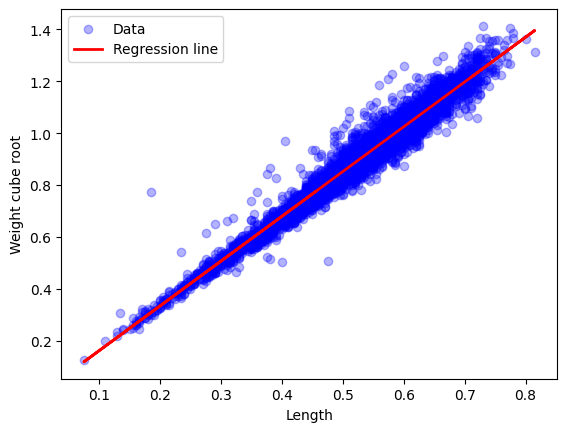

In [19]:
# plot
plt.scatter(X_reg, y_reg, alpha=0.3, color='blue', label='Data')
plt.plot(X_reg, line, color='red', linewidth=2, label='Regression line')
plt.xlabel('Length')
plt.ylabel('Weight cube root')
plt.legend()
plt.show()

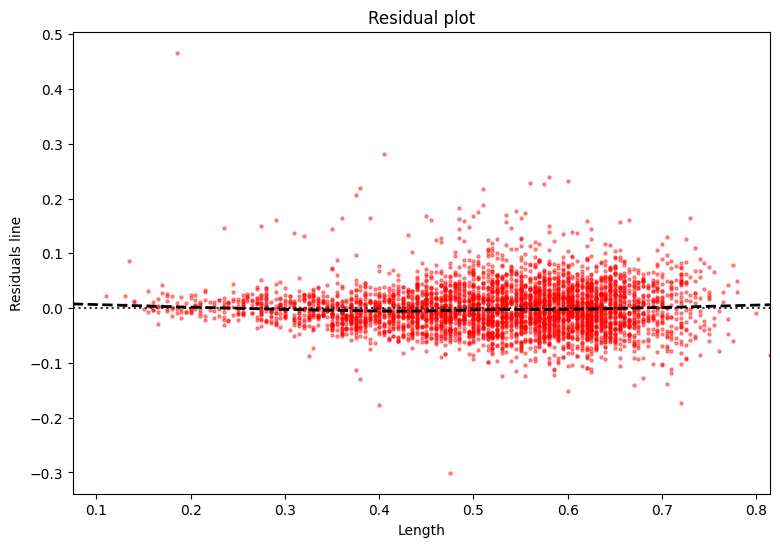

In [ ]:
# 9) error visualization - create a residual plot. Identify if the
# variance is constant

import seaborn as sns

plt.figure(figsize=(9, 6))
sns.residplot(
    x=X['Length'],
    y=np.cbrt(X['Whole_weight']),
    lowess=True,
    scatter_kws={'s':5, 'alpha' : 0.4, 'color' : 'red'},
    line_kws={'color': 'black', 'linestyle' : '--', 'linewidth' : 2}
)
plt.title('Residual plot')
plt.xlabel('Length')
plt.ylabel('Residuals line')
plt.show()

# variance is not constant, because as the length increases dots start being
# all over the place

In [ ]:
# 10) statistical error check: calculate the mean, sd
# and variance of the residuals

import statistics

predictions = model.predict(X_reg)
residuals= y_reg - predictions
print(f'Mean of the residuals = ', np.mean(residuals))
print(f'Standard deviation of the residuals = ', np.std(residuals))
print(f'Variance of the residuals = ', statistics.variance(residuals))


Mean of the residuals =  1.0472297622751057e-16
Standard deviation of the residuals =  0.04315328939871089
Variance of the residuals =  0.0018626523165768648


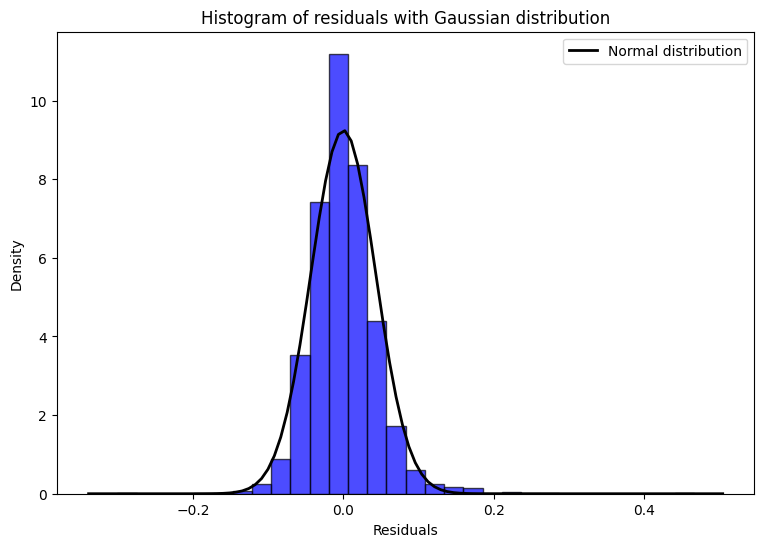

In [26]:
# 11) plot a histogram of residuals and overlay it with a theoretical
# normal distribution curve. Create a QQ-plot for the residuals

import scipy.stats as stats
from scipy.stats import norm

plt.figure(figsize=(9,6))
plt.hist(residuals, density=True, bins=30, color='blue', edgecolor='black', alpha=0.7)

xmin, xmax = plt.xlim()
x_axis = np.linspace(xmin, xmax, 100)

p = norm.pdf(x_axis, np.mean(residuals), np.std(residuals))

plt.plot(x_axis, p, 'k', linewidth=2, label='Normal distribution')
plt.title('Histogram of residuals with Gaussian distribution')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.legend()
plt.show()

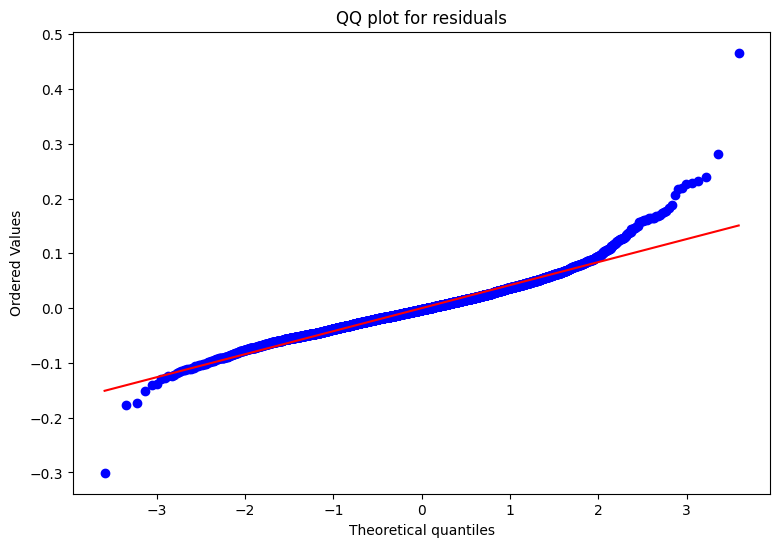

In [27]:
# qq plot

plt.figure(figsize=(9,6))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('QQ plot for residuals')
plt.show()

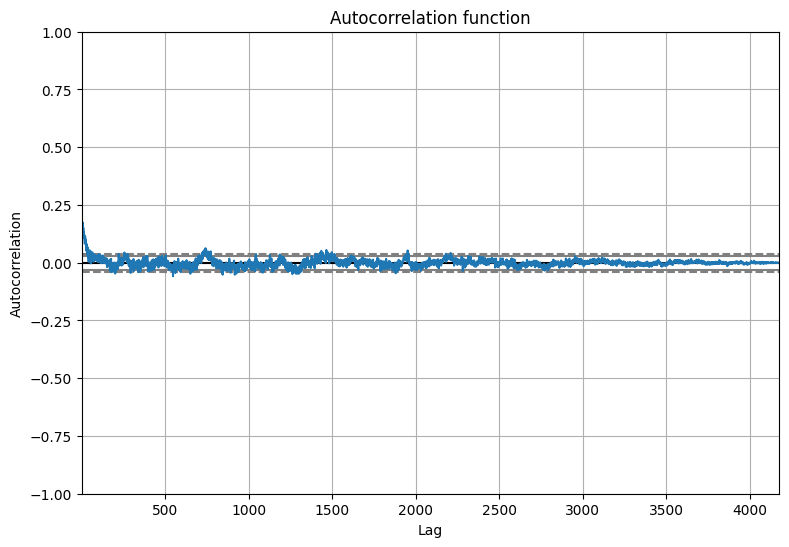

In [ ]:
# 12) plot the autocorrelation function acf for the residuals

plt.figure(figsize=(9,6))
pd.plotting.autocorrelation_plot(residuals)
plt.title('Autocorrelation function')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

# almost the entire line stays tightly within the grey confidence bands
# across the entire dataset, therefore we can say with certainty that
# the residuals are in fact independent, meaning that autocorrelation
# does not occur

C:\Users\huber\AppData\Local\Temp\ipykernel_22476\154407179.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


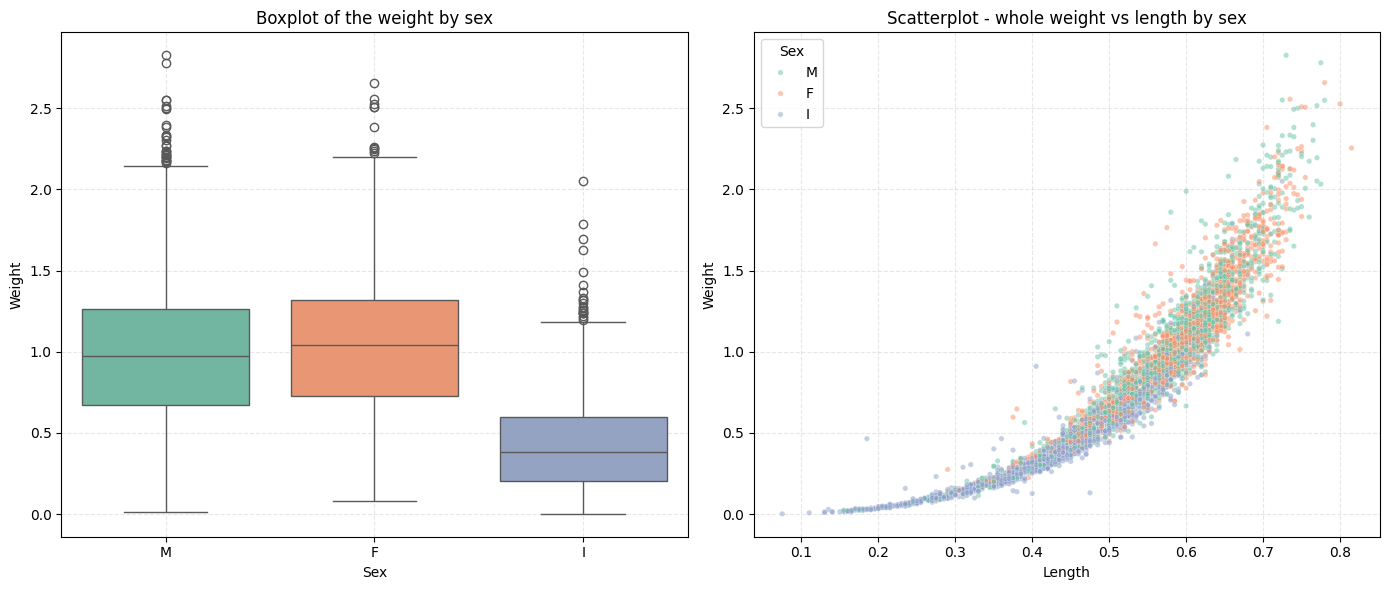

In [31]:
# 13) present boxplots of whole weight segmented by the categorical
# variable sex (male,female,infant). Present a scatterplot of whole
# weight vs length colored by sex

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=X, 
    x='Sex',  # grouping people by sex
    y='Whole_weight',
    ax=axes[0], # left subplot (index 0 - first)
    order=['M', 'F', 'I'],
    palette='Set2' # preset colors
)

axes[0].set_title('Boxplot of the weight by sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Weight')
axes[0].grid(True, linestyle='--', alpha=0.3)

sns.scatterplot(
    data=X, 
    x='Length', 
    y='Whole_weight', 
    hue='Sex', # coloring by sex
    ax=axes[1], # right subplot (index 1 - second)
    alpha=0.5,
    s=15, # small size for visibility 
    hue_order=['M', 'F', 'I'], 
    palette='Set2' # preset colors
)

axes[1].set_title('Scatterplot - whole weight vs length by sex')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Weight')
axes[1].grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

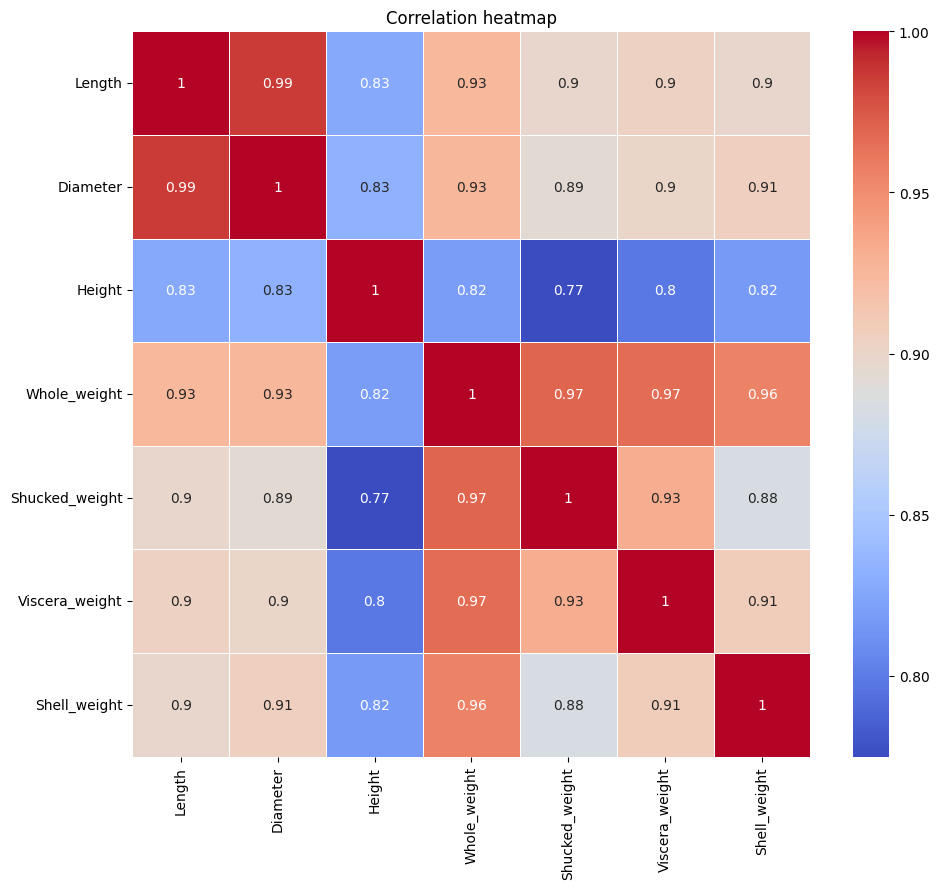

In [32]:
# 14) generate a correlation heatmap for the entire feature set

X_heatmap = X.drop(columns=['Sex'])
correlationmatrix = X_heatmap.corr()

plt.figure(figsize=(10,9))
sns.heatmap(correlationmatrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation heatmap')

plt.tight_layout()
plt.show()